# CVB Dataset Analysis

**Dataset:** Cattle Video Behavior (CVB)  
**Notebook:** `notebooks/dataset_analysis/analysis_cvb.ipynb`  
**Output:** `results/analysis/cvb_summary.json`

Derives all statistics from `data/raw/cvb/` only. No pipeline outputs are read.


In [2]:
import sys, os, re, json, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path("../..")
sys.path.insert(0, str(REPO_ROOT))
from src.data.label_utils import (
    LABEL_NAMES,
    _CVB_BEHAVIOR_MAP,
    cvb_behavior_to_label,
    load_cvb_splits,
)

RAW = REPO_ROOT / "data" / "raw" / "cvb"
RESULTS_DIR = REPO_ROOT / "results" / "analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ANN_DIR = RAW / "annotations"
FRAMES_DIR = RAW / "raw_frames"
AVA_DIR = RAW / "cvb_in_ava_format"

print("RAW path:", RAW.resolve())
print("Annotation clips:", len(list(ANN_DIR.iterdir())))
print("Frame clip dirs:", len(list(FRAMES_DIR.iterdir())))

RAW path: /home/sakif/TXST/Thesis/cattle-vision-framework/data/raw/cvb
Annotation clips: 502
Frame clip dirs: 502


---

## 1. Dataset Overview

**Origin:** CVB is an outdoor pasture dataset captured from GoPro cameras mounted at the four corners of a paddock arm (`arm01`). Recordings cover multiple nights in March 2020.

**Paper:** _"A Top-Down Approach to Cattle Behavior Recognition in the Wild Using Video Analysis"_ (CVB release). The dataset was annotated using a COCO-format toolchain and released with an AVA-compatible split CSV for use in activity recognition pipelines.

**License:** Research use only.

**Annotation format:** Per-clip COCO JSON — one file per clip at `annotations/{clip_id}/annotations/instances_default.json`. Each annotation object has a `behavior` string in its `attributes` dict. Behaviors are encoded in the clip folder name as `beh{N}` (folder-level primary behavior of the focal animal), and per-annotation as free strings that map to the 7-class taxonomy via `_CVB_BEHAVIOR_MAP`.

**CVB behavior string → canonical taxonomy:**

| CVB behavior string               | Canonical ID | Canonical name   | Notes    |
| --------------------------------- | ------------ | ---------------- | -------- |
| resting-standing                  | 0            | Standing         |          |
| resting-lying                     | 1            | Lying            |          |
| grazing                           | 2            | Foraging/Grazing |          |
| drinking                          | 3            | Drinking         |          |
| ruminating-standing               | 4            | Ruminating       |          |
| ruminating-lying                  | 4            | Ruminating       | merged   |
| grooming                          | 5            | Grooming         | CVB only |
| other                             | 6            | Other            | CVB only |
| hidden / walking / running / none | —            | (SKIP)           | excluded |

**Role in thesis pipeline:**

- **Training dataset** for behavior classifier (VideoMAE configs 2, 3, 5)
- **In-domain evaluation** for config 2 (CVB val set)
- **Cross-domain target** for config 3 (trained on CBVD-5, evaluated on CVB)
- **Cross-domain source** for config 4 (trained on CVB, evaluated on CBVD-5)

**beh{N} folder encoding** (from `cvb_in_ava_format/behaviour_list.pbtx`):

| beh N | CVB string          | Canonical |
| ----- | ------------------- | --------- |
| 1     | none                | SKIP      |
| 2     | grazing             | 2         |
| 3     | walking             | SKIP      |
| 4     | ruminating-standing | 4         |
| 5     | ruminating-lying    | 4         |
| 6     | resting-standing    | 0         |
| 7     | resting-lying       | 1         |
| 8     | drinking            | 3         |
| 9     | grooming            | 5         |
| 10    | other               | 6         |
| 11    | hidden              | SKIP      |
| 12    | running             | SKIP      |


---

## 2. Data Inventory


In [3]:
clip_dirs = sorted(ANN_DIR.iterdir())
n_clips = len(clip_dirs)

# Parse clip folder name components: {id}_{arm}_{camera}_{date}_{time}_beh{N}_ani{N}_ins{N}_cut_{N}
clip_meta = []
for d in clip_dirs:
    parts = d.name.split("_")
    camera = next((p for p in parts if p.startswith("gopro")), None)
    beh_part = next((p for p in parts if re.match(r"beh\d+", p)), None)
    beh_n = int(beh_part[3:]) if beh_part else None
    clip_meta.append({"clip_id": d.name, "camera": camera, "beh_n": beh_n})

df_clips = pd.DataFrame(clip_meta)

# Splits from AVA-format CSV (first column = clip_id)
splits_map = load_cvb_splits()
df_clips["split"] = df_clips["clip_id"].map(splits_map)

# Frame counts
total_frames_on_disk = sum(
    len(list((FRAMES_DIR / d.name).glob("img_*.jpg")))
    for d in clip_dirs
    if (FRAMES_DIR / d.name).exists()
)

# AVA CSV row counts (frame-level annotations)
ava_train_rows = sum(1 for _ in open(AVA_DIR / "ava_train_set.csv"))
ava_val_rows = sum(1 for _ in open(AVA_DIR / "ava_val_set.csv"))

print(f"Total clips:              {n_clips:>6}")
print(f"  Train clips:            {df_clips.split.eq('train').sum():>6}")
print(f"  Val clips:              {df_clips.split.eq('val').sum():>6}")
print(f"  Unassigned (skip beh):  {df_clips.split.isna().sum():>6}")
print(f"Total frames on disk:     {total_frames_on_disk:>6,}")
print(f"AVA train annotation rows:{ava_train_rows:>6,}")
print(f"AVA val annotation rows:  {ava_val_rows:>6,}")
print()
print("Camera breakdown:")
print(df_clips["camera"].value_counts().to_string())

Total clips:                 502
  Train clips:               358
  Val clips:                  89
  Unassigned (skip beh):      55
Total frames on disk:     225,829
AVA train annotation rows:926,330
AVA val annotation rows:  230,879

Camera breakdown:
camera
gopro1    260
gopro4    204
gopro3     38


---

## 3. Sample Image Visualization


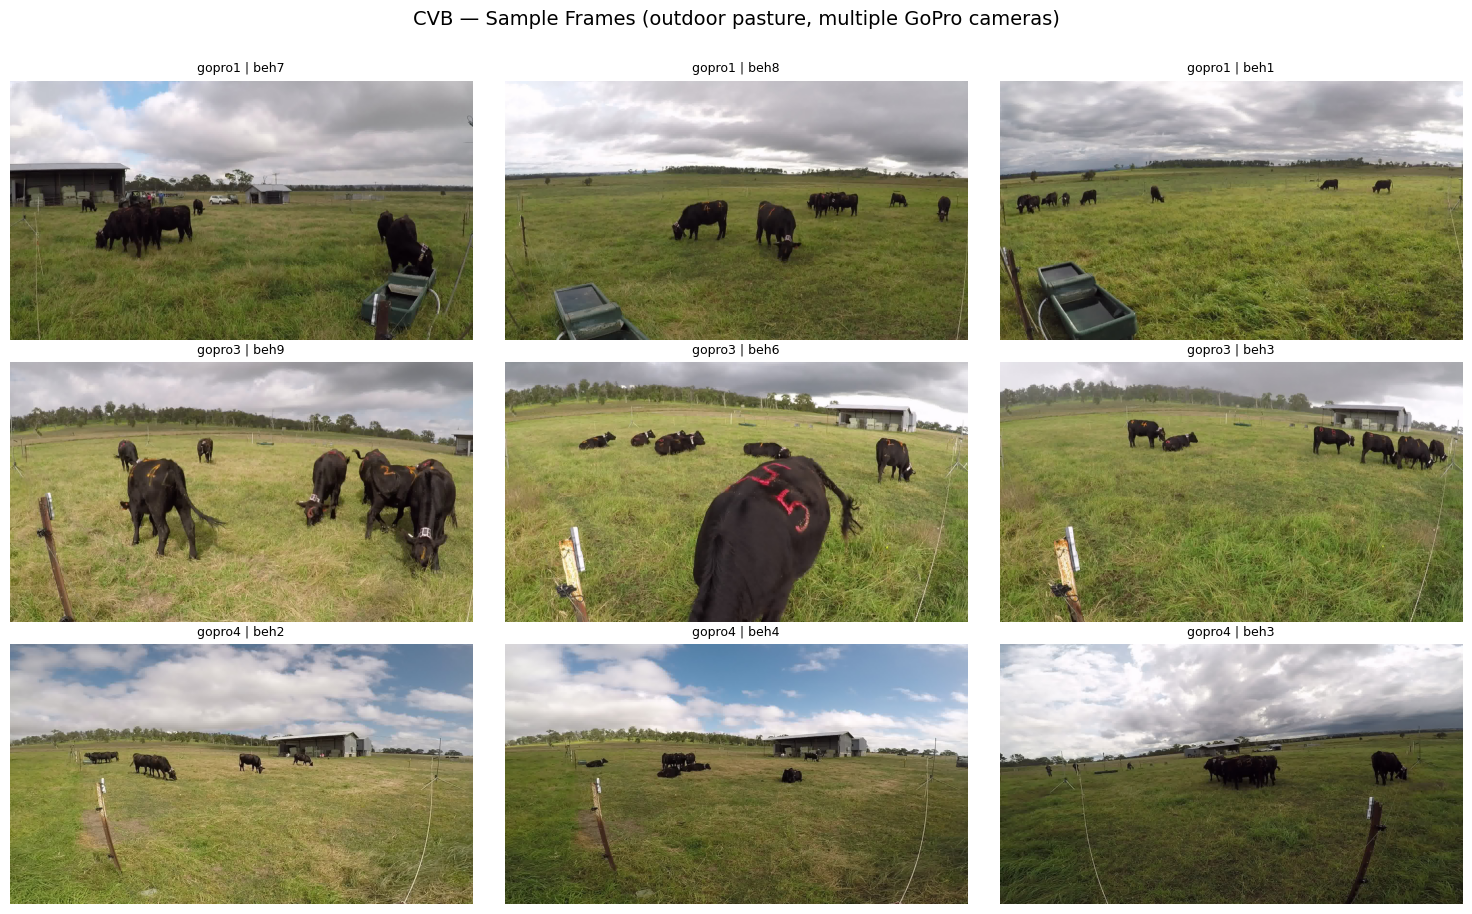

Saved: results/analysis/cvb_sample_frames.png


In [4]:
# Pick 9 frames: one from each of 9 different clips spread across cameras and behaviors
cameras = sorted(df_clips["camera"].dropna().unique())
sample_clips = []
for cam in cameras:
    cam_clips = df_clips[df_clips["camera"] == cam]["clip_id"].tolist()
    # pick 3 evenly spaced from each camera
    step = max(1, len(cam_clips) // 3)
    sample_clips.extend(cam_clips[::step][:3])
sample_clips = sample_clips[:9]

sample_frames = []
for clip_id in sample_clips:
    frame_dir = FRAMES_DIR / clip_id
    if frame_dir.exists():
        imgs = sorted(frame_dir.glob("img_*.jpg"))
        if imgs:
            sample_frames.append((clip_id, imgs[len(imgs) // 2]))

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
fig.suptitle(
    "CVB — Sample Frames (outdoor pasture, multiple GoPro cameras)", fontsize=14, y=1.01
)

for ax, (clip_id, fpath) in zip(axes.flat, sample_frames):
    img = Image.open(fpath)
    ax.imshow(img)
    cam = next((p for p in clip_id.split("_") if p.startswith("gopro")), "")
    beh = next((p for p in clip_id.split("_") if p.startswith("beh")), "")
    ax.set_title(f"{cam} | {beh}", fontsize=9)
    ax.axis("off")

for ax in axes.flat[len(sample_frames) :]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cvb_sample_frames.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/analysis/cvb_sample_frames.png")

---

## 4. Annotation Format


In [5]:
# Parse one sample COCO JSON and display its structure
sample_clip_dir = clip_dirs[0]
sample_json_path = sample_clip_dir / "annotations" / "instances_default.json"

with open(sample_json_path) as f:
    sample_data = json.load(f)

print(f"=== COCO JSON: {sample_clip_dir.name} ===")
print(f"Top-level keys:   {list(sample_data.keys())}")
print(f"Images:           {len(sample_data['images'])}")
print(f"Annotations:      {len(sample_data['annotations'])}")
print(f"Categories:       {sample_data['categories']}")
print()
print("Sample image entry (images[0]):")
img0 = sample_data["images"][0]
for k, v in img0.items():
    print(f"  {k:<18} = {v}")
print()
print("Sample annotation entry (annotations[0]):")
ann0 = sample_data["annotations"][0]
for k, v in ann0.items():
    print(f"  {k:<18} = {v}")
print()
print("Key fields:")
print("  image_id         — matches img_{image_id:05d}.jpg frame filename")
print("  bbox             — COCO format [x, y, width, height] in absolute pixels")
print(
    "  attributes.behavior — free string; mapped to canonical ID via _CVB_BEHAVIOR_MAP"
)
print("  attributes.track_id — per-clip instance tracking ID")

=== COCO JSON: 0002_arm01_gopro1_20200322_222554_beh7_ani1_ins1_cut_1 ===
Top-level keys:   ['licenses', 'info', 'categories', 'images', 'annotations']
Images:           450
Annotations:      3600
Categories:       [{'id': 1, 'name': 'cow', 'supercategory': ''}]

Sample image entry (images[0]):
  id                 = 1
  width              = 1920
  height             = 1080
  file_name          = cattle/raw_frames_15sec_subset1/0002_arm01_gopro1_20200322_222554_beh7_ani1_ins1_cut_1/img_00001.jpg
  license            = 0
  flickr_url         = 
  coco_url           = 
  date_captured      = 0

Sample annotation entry (annotations[0]):
  id                 = 1
  image_id           = 1
  category_id        = 1
  segmentation       = []
  area               = 4422.268800000002
  bbox               = [279.32, 493.95, 69.84, 63.32]
  iscrowd            = 0
  attributes         = {'behavior': 'grazing', 'id': 'unknown', 'occluded': False, 'rotation': 0.0, 'track_id': 0, 'keyframe': True}

Key

In [6]:
# Show all unique behavior strings found across all annotations in this one clip
behaviors_in_clip = {
    ann["attributes"]["behavior"] for ann in sample_data["annotations"]
}
print(f"Unique behavior strings in {sample_clip_dir.name}:")
for b in sorted(behaviors_in_clip):
    cid = cvb_behavior_to_label(b)
    cname = LABEL_NAMES[cid] if cid is not None else "SKIP"
    print(f"  {b:<25} → canonical ID {cid if cid is not None else '—':>2}  ({cname})")

Unique behavior strings in 0002_arm01_gopro1_20200322_222554_beh7_ani1_ins1_cut_1:
  drinking                  → canonical ID  3  (Drinking)
  grazing                   → canonical ID  2  (Foraging)
  hidden                    → canonical ID  —  (SKIP)
  other                     → canonical ID  6  (Other)
  walking                   → canonical ID  —  (SKIP)


---

## 5. Class Distribution


In [7]:
# Read all 502 COCO JSONs and accumulate behavior string counts per split
raw_behavior_counts: dict[str, int] = collections.Counter()
canonical_counts: dict[str, collections.Counter] = {
    "train": collections.Counter(),
    "val": collections.Counter(),
    "all": collections.Counter(),
}
total_annotations = 0
skipped_annotations = 0

for clip_dir in clip_dirs:
    json_path = clip_dir / "annotations" / "instances_default.json"
    if not json_path.exists():
        continue
    split = splits_map.get(clip_dir.name, "unassigned")
    with open(json_path) as f:
        data = json.load(f)
    for ann in data["annotations"]:
        behavior = ann["attributes"]["behavior"]
        raw_behavior_counts[behavior] += 1
        cid = cvb_behavior_to_label(behavior)
        if cid is None:
            skipped_annotations += 1
        else:
            canonical_counts["all"][cid] += 1
            if split in ("train", "val"):
                canonical_counts[split][cid] += 1
        total_annotations += 1

print(f"Total annotation instances: {total_annotations:,}")
print(f"  Mapped to canonical IDs:  {total_annotations - skipped_annotations:,}")
print(f"  Skipped (SKIP behaviors): {skipped_annotations:,}")
print()
print("Raw CVB behavior string counts (all clips):")
for beh, cnt in sorted(raw_behavior_counts.items(), key=lambda x: -x[1]):
    cid = cvb_behavior_to_label(beh)
    cname = LABEL_NAMES[cid] if cid is not None else "SKIP"
    print(f"  {beh:<25} {cnt:>8,}   → {cname}")

Total annotation instances: 1,163,408
  Mapped to canonical IDs:  1,024,776
  Skipped (SKIP behaviors): 138,632

Raw CVB behavior string counts (all clips):
  grazing                    496,394   → Foraging
  resting-lying              208,586   → Lying
  resting-standing           137,987   → Standing
  hidden                     107,915   → SKIP
  ruminating-lying            75,864   → Ruminating
  drinking                    33,379   → Drinking
  ruminating-standing         29,239   → Ruminating
  other                       26,637   → Other
  walking                     23,929   → SKIP
  grooming                    16,690   → Grooming
  none                         5,056   → SKIP
  running                      1,732   → SKIP


In [8]:
print("Canonical class distribution (mapped annotations only):")
print(f"{'ID':<4} {'Name':<20} {'Train':>10} {'Val':>10} {'Total':>10}")
print("-" * 56)
for cid in sorted(canonical_counts["all"].keys()):
    tr = canonical_counts["train"][cid]
    vl = canonical_counts["val"][cid]
    tot = canonical_counts["all"][cid]
    print(f"{cid:<4} {LABEL_NAMES[cid]:<20} {tr:>10,} {vl:>10,} {tot:>10,}")
print("-" * 56)
tr_total = sum(canonical_counts["train"].values())
vl_total = sum(canonical_counts["val"].values())
all_total = sum(canonical_counts["all"].values())
print(f"{'TOTAL':<24} {tr_total:>10,} {vl_total:>10,} {all_total:>10,}")

Canonical class distribution (mapped annotations only):
ID   Name                      Train        Val      Total
--------------------------------------------------------
0    Standing                113,353     24,634    137,987
1    Lying                   169,904     38,682    208,586
2    Foraging                395,929    100,465    496,394
3    Drinking                 26,225      7,154     33,379
4    Ruminating               76,969     28,134    105,103
5    Grooming                 14,091      2,599     16,690
6    Other                    22,851      3,786     26,637
--------------------------------------------------------
TOTAL                       819,322    205,454  1,024,776


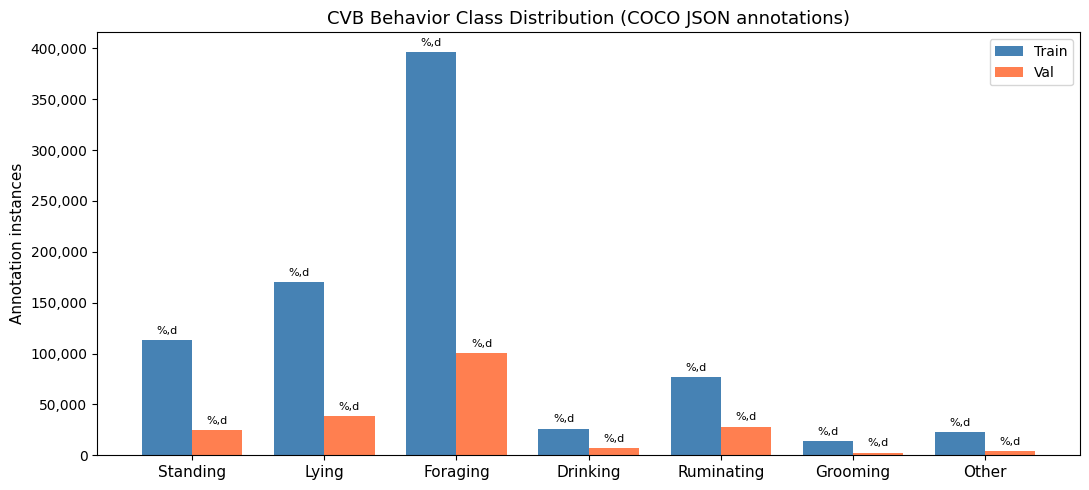

Saved: results/analysis/cvb_class_distribution.png


In [9]:
label_ids = sorted(canonical_counts["all"].keys())
label_names = [LABEL_NAMES[i] for i in label_ids]
train_vals = [canonical_counts["train"][i] for i in label_ids]
val_vals = [canonical_counts["val"][i] for i in label_ids]

x = np.arange(len(label_ids))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width / 2, train_vals, width, label="Train", color="steelblue")
bars2 = ax.bar(x + width / 2, val_vals, width, label="Val", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(label_names, fontsize=11)
ax.set_ylabel("Annotation instances", fontsize=11)
ax.set_title("CVB Behavior Class Distribution (COCO JSON annotations)", fontsize=13)
ax.legend()
ax.bar_label(bars1, fmt="%,d", fontsize=8, padding=3)
ax.bar_label(bars2, fmt="%,d", fontsize=8, padding=3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cvb_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/analysis/cvb_class_distribution.png")

**Observations:**

- Resting-lying (Lying) and resting-standing (Standing) dominate, reflecting overnight pasture recordings where cows spend most time at rest.
- Grazing (Foraging) is well-represented given outdoor pasture setting.
- Drinking is the rarest active behavior — trough visits are brief.
- Grooming and Other appear only in CVB (not in CBVD-5); their presence expands the 7-class taxonomy.


---

## 6. Resolution & Quality


In [10]:
# Sample resolutions from annotation JSON (width/height in images list)
resolutions: collections.Counter = collections.Counter()
sample_clip_count = 0
for clip_dir in clip_dirs[::10]:  # sample every 10th clip
    json_path = clip_dir / "annotations" / "instances_default.json"
    if not json_path.exists():
        continue
    with open(json_path) as f:
        data = json.load(f)
    for img in data["images"][:1]:
        resolutions[(img["width"], img["height"])] += 1
    sample_clip_count += 1

dominant_res = resolutions.most_common(1)[0][0]
print(f"Checked {sample_clip_count} clips (sampled every 10th)")
print(f"Resolutions found: {dict(resolutions)}")
print(f"Dominant resolution: {dominant_res[0]}×{dominant_res[1]} px")

# Frames per clip distribution
frame_counts = []
for clip_dir in clip_dirs[::20]:  # sample every 20th
    fd = FRAMES_DIR / clip_dir.name
    if fd.exists():
        frame_counts.append(len(list(fd.glob("img_*.jpg"))))

if frame_counts:
    print(f"\nFrame counts per clip (sampled {len(frame_counts)} clips):")
    print(
        f"  Min: {min(frame_counts)}  Max: {max(frame_counts)}  Median: {int(np.median(frame_counts))}  Mean: {np.mean(frame_counts):.1f}"
    )

Checked 51 clips (sampled every 10th)
Resolutions found: {(1920, 1080): 51}
Dominant resolution: 1920×1080 px

Frame counts per clip (sampled 26 clips):
  Min: 450  Max: 450  Median: 450  Mean: 450.0


In [11]:
# Missing frame check: compare annotated image filenames against files on disk
# This is the known CVB gotcha: not all annotated frames have corresponding images
total_annotated_images = 0
total_missing_images = 0
clips_with_missing = 0

for clip_dir in clip_dirs:
    json_path = clip_dir / "annotations" / "instances_default.json"
    if not json_path.exists():
        continue
    with open(json_path) as f:
        data = json.load(f)

    frame_dir = FRAMES_DIR / clip_dir.name
    on_disk = (
        set(p.name for p in frame_dir.glob("img_*.jpg"))
        if frame_dir.exists()
        else set()
    )

    missing = 0
    for img_entry in data["images"]:
        fname = Path(img_entry["file_name"]).name
        total_annotated_images += 1
        if fname not in on_disk:
            missing += 1
            total_missing_images += 1

    if missing > 0:
        clips_with_missing += 1

print(f"Total annotated image entries:    {total_annotated_images:,}")
print(
    f"Missing on disk:                  {total_missing_images:,}  ({100*total_missing_images/total_annotated_images:.1f}%)"
)
print(f"Clips with at least one missing:  {clips_with_missing} / {n_clips}")
if total_missing_images > 0:
    print()
    print(
        "⚠️  Missing frames are a known CVB issue. src/data/convert_cvb.py filters to present frames only."
    )
else:
    print("\n✅ No missing frames detected.")

Total annotated image entries:    225,829
Missing on disk:                  0  (0.0%)
Clips with at least one missing:  0 / 502

✅ No missing frames detected.


---

## 7. Label Mapping to 7-class Taxonomy


In [12]:
print("CVB → 7-class canonical taxonomy mapping")
print("=" * 68)
print(
    f"{'CVB behavior string':<28} {'Canonical ID':<14} {'Canonical name':<18} {'Status'}"
)
print("-" * 68)

# Ordered by canonical ID for readability
cvb_behaviors_ordered = [
    ("resting-standing", 0, "mapped"),
    ("resting-lying", 1, "mapped"),
    ("grazing", 2, "mapped"),
    ("drinking", 3, "mapped"),
    ("ruminating-standing", 4, "merged→4"),
    ("ruminating-lying", 4, "merged→4"),
    ("grooming", 5, "CVB only"),
    ("other", 6, "CVB only"),
    ("none", None, "SKIP"),
    ("walking", None, "SKIP"),
    ("running", None, "SKIP"),
    ("hidden", None, "SKIP"),
]

for beh_str, cid, note in cvb_behaviors_ordered:
    cid_str = str(cid) if cid is not None else "—"
    cname = LABEL_NAMES[cid] if cid is not None else "(excluded)"
    print(f"{beh_str:<28} {cid_str:<14} {cname:<18} {note}")

print()
print(
    "Note: ruminating-standing and ruminating-lying both map to canonical ID 4 (Ruminating)."
)
print("      SKIP behaviors are excluded from tubelet generation and training.")
print("      Logic implemented in: src/data/label_utils.py :: cvb_behavior_to_label()")

CVB → 7-class canonical taxonomy mapping
CVB behavior string          Canonical ID   Canonical name     Status
--------------------------------------------------------------------
resting-standing             0              Standing           mapped
resting-lying                1              Lying              mapped
grazing                      2              Foraging           mapped
drinking                     3              Drinking           mapped
ruminating-standing          4              Ruminating         merged→4
ruminating-lying             4              Ruminating         merged→4
grooming                     5              Grooming           CVB only
other                        6              Other              CVB only
none                         —              (excluded)         SKIP
walking                      —              (excluded)         SKIP
running                      —              (excluded)         SKIP
hidden                       —              (exc

---

## 8. Preprocessing Gap Analysis


In [13]:
print("Preprocessing steps required before CVB enters the pipeline:")
print()
print("1. Frame filtering (src/data/convert_cvb.py)")
print("   - Reads each per-clip COCO JSON from data/raw/cvb/annotations/")
print(
    "   - Filters to image entries where the corresponding img_*.jpg file exists on disk"
)
print("   - Skips annotations whose behavior maps to None (SKIP behaviors)")
print("   - Outputs per-frame YOLO .txt label files for detection training")
print()
print("2. Behavior label extraction")
print("   - Each annotation's behavior string is mapped via _CVB_BEHAVIOR_MAP")
print("   - ruminating-standing and ruminating-lying both collapse to canonical ID 4")
print("   - SKIP behaviors (none, walking, running, hidden) are excluded entirely")
print()
print("3. Train/val split")
print("   - Clip IDs appearing in ava_train_set.csv → train")
print("   - Clip IDs appearing in ava_val_set.csv   → val")
print(f"   - Train clips: {df_clips.split.eq('train').sum()}")
print(f"   - Val clips:   {df_clips.split.eq('val').sum()}")
print(f"   - Unassigned:  {df_clips.split.isna().sum()} clips not in either split CSV")
print(
    "   - ⚠️  No separate test split. Val is used for in-domain evaluation (config 2)."
)
print()
print("4. Detection inference (script 06_run_detection.sh)")
print("   - RF-DETR runs on CVB raw frames to produce bounding box detections")
print("   - Detections replace ground-truth boxes for the tracking stage")
print()
print("5. Tubelet generation (script 09_generate_tubelets.sh)")
print("   - 16-frame clips, stride 4, 224×224 px")
print("   - Requires tracking_v2 outputs (OC-SORT tracks from RF-DETR detections)")

Preprocessing steps required before CVB enters the pipeline:

1. Frame filtering (src/data/convert_cvb.py)
   - Reads each per-clip COCO JSON from data/raw/cvb/annotations/
   - Filters to image entries where the corresponding img_*.jpg file exists on disk
   - Skips annotations whose behavior maps to None (SKIP behaviors)
   - Outputs per-frame YOLO .txt label files for detection training

2. Behavior label extraction
   - Each annotation's behavior string is mapped via _CVB_BEHAVIOR_MAP
   - ruminating-standing and ruminating-lying both collapse to canonical ID 4
   - SKIP behaviors (none, walking, running, hidden) are excluded entirely

3. Train/val split
   - Clip IDs appearing in ava_train_set.csv → train
   - Clip IDs appearing in ava_val_set.csv   → val
   - Train clips: 358
   - Val clips:   89
   - Unassigned:  55 clips not in either split CSV
   - ⚠️  No separate test split. Val is used for in-domain evaluation (config 2).

4. Detection inference (script 06_run_detection.sh)


---

## 9. Summary JSON + Self-Consistency Check


In [14]:
# Build class_distribution from canonical counts (all splits combined)
class_dist = {
    str(cid): int(cnt) for cid, cnt in sorted(canonical_counts["all"].items())
}

summary = {
    "dataset": "cvb",
    "total_images_or_frames": total_frames_on_disk,
    "total_annotations": total_annotations - skipped_annotations,
    "splits": {
        "train": int(df_clips.split.eq("train").sum()),
        "val": int(df_clips.split.eq("val").sum()),
        "test": 0,
    },
    "class_distribution": class_dist,
    "resolution": {"width": dominant_res[0], "height": dominant_res[1]},
    "has_behavior_labels": True,
    "evaluation_scope": [
        "behavior_f1",
        "in_domain",
        "cross_domain_source",
        "cross_domain_target",
    ],
}

# Schema validation
required_keys = [
    "dataset",
    "total_images_or_frames",
    "total_annotations",
    "splits",
    "class_distribution",
    "resolution",
    "has_behavior_labels",
    "evaluation_scope",
]
missing_keys = [k for k in required_keys if k not in summary]
assert not missing_keys, f"Missing schema keys: {missing_keys}"

non_int = {
    k: v
    for k, v in summary["class_distribution"].items()
    if not isinstance(v, int) or v == 0
}
assert not non_int, f"class_distribution has zero or non-int values: {non_int}"

out_path = RESULTS_DIR / "cvb_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Summary JSON:")
print(json.dumps(summary, indent=2))
print(f"\n✅ Saved: {out_path}")

Summary JSON:
{
  "dataset": "cvb",
  "total_images_or_frames": 225829,
  "total_annotations": 1024776,
  "splits": {
    "train": 358,
    "val": 89,
    "test": 0
  },
  "class_distribution": {
    "0": 137987,
    "1": 208586,
    "2": 496394,
    "3": 33379,
    "4": 105103,
    "5": 16690,
    "6": 26637
  },
  "resolution": {
    "width": 1920,
    "height": 1080
  },
  "has_behavior_labels": true,
  "evaluation_scope": [
    "behavior_f1",
    "in_domain",
    "cross_domain_source",
    "cross_domain_target"
  ]
}

✅ Saved: ../../results/analysis/cvb_summary.json


In [15]:
# Self-consistency check against known CVB dataset statistics
print("Self-consistency check:")
print("=" * 60)

checks = [
    ("Total clips (annotations/)", n_clips, 502, "== 502 (paper)"),
    (
        "Train clips",
        int(df_clips.split.eq("train").sum()),
        358,
        "== 358 (from ava_train_set.csv)",
    ),
    (
        "Val clips",
        int(df_clips.split.eq("val").sum()),
        89,
        "== 89  (from ava_val_set.csv)",
    ),
    ("Frame resolution W", dominant_res[0], 1920, "== 1920"),
    ("Frame resolution H", dominant_res[1], 1080, "== 1080"),
]

all_ok = True
for name, computed, expected, note in checks:
    ok = computed == expected
    status = "✅" if ok else "⚠️ "
    if not ok:
        all_ok = False
    print(f"{status} {name:<35} computed={computed:>6}  expected={expected:>6}  {note}")

print()
if all_ok:
    print("✅ All checks passed.")
else:
    print("⚠️  Some checks failed — review the values above.")

Self-consistency check:
✅ Total clips (annotations/)          computed=   502  expected=   502  == 502 (paper)
✅ Train clips                         computed=   358  expected=   358  == 358 (from ava_train_set.csv)
✅ Val clips                           computed=    89  expected=    89  == 89  (from ava_val_set.csv)
✅ Frame resolution W                  computed=  1920  expected=  1920  == 1920
✅ Frame resolution H                  computed=  1080  expected=  1080  == 1080

✅ All checks passed.
